# Ratio Analysis from makeRatioBinned3D output

Reads raw `hRatio`, `hRatio_k`, `hRatio_r` histograms, applies kaon/rho corrections,
optionally sums over any combination of the var / Q² / xB dimensions, then computes
the charge ratio and asymmetry A(z) = (4 − r) / (4r − 1).

In [179]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

## Configuration

In [180]:
# Input file produced by makeRatioBinned3D
IN_FILE = "../histograms/analysis_note/ratios_2d_k_Mx.root"

# applyCorr value used when running makeRatioBinned3D
# > 3: kaon correction applied (hRatio_k present)
# > 4: rho correction applied (hRatio_r present)
APPLY_CORR = 4

# Variable binning (bins_var from the run; 1 = no extra variable)
BINS_VAR = 5

# --- Summation options ---
# SUM_VAR:
#   False       : show each var bin as a separate curve
#   True        : sum over all var bins
#   (lo, hi)    : sum only over var bins whose range overlaps [lo, hi] in physical units
# SUM_Q2 / SUM_XB: True = sum over all bins in that dimension
SUM_VAR = False   # e.g. True, or (0.4, 1.2)
SUM_Q2  = False
SUM_XB  = True

# --- Overlay options (at most one may be True) ---
# OVERLAY_Q2: one figure per xB bin with Q2 bins shown as separate curves
# OVERLAY_XB: one figure per Q2 bin with xB bins shown as separate curves
# Both False  : original behavior — one figure per (Q2, xB) pair, var bins as curves
OVERLAY_Q2 = True
OVERLAY_XB = False

# Variable info for axis labels (used when BINS_VAR > 1)
VAR_LABEL = r'$M_X$'
VAR_MIN   = 1.7
VAR_MAX   = 6.7
VAR_UNIT  = 'GeV'

# Kinematic bin definitions (must match cut_values.h)
BINS_Q2 = 12
BINS_XB = 14
BINS_Z  = 14
Q2_MIN, Q2_MAX = 2.0, 8.0
XB_MIN, XB_MAX = 0.1, 0.66

# Plot output directory (None = display inline only)
OUT_DIR = None  # e.g. "ratio_plots"

## Helpers

In [181]:
def ff(z):
    """Fragmentation function baseline: (1-z)/(1+z)"""
    DS = (4*z**2)/3 + 2/(3*z)
    DN = (2/5)*np.sqrt(z)*(np.sqrt(15)*np.sin(np.sqrt(5/12)*np.log(z)) + 5 *np.cos(np.sqrt(5/12)*np.log(z)))
    
    dp = (1/3)*(DS + DN)
    dm = (1/3)*(DS - DN)

    #return dm/dp

    return (1 - z) / (1 + z)


def get_hist(f, name):
    """Return (values, errors, bin_centers) or None if histogram absent."""
    key = name + ";1"
    if key not in f:
        if name not in f:
            return None
        key = name
    h = f[key]
    edges = h.axis().edges()
    centers = (edges[:-1] + edges[1:]) / 2
    return np.array(h.values()), np.array(h.errors()), centers


def ratio_hists(num_v, num_e, den_v, den_e):
    """Element-wise ratio num/den with propagated errors."""
    with np.errstate(invalid='ignore', divide='ignore'):
        r = np.where(den_v != 0, num_v / den_v, np.nan)
        r_e = np.where(
            (den_v != 0) & (num_v != 0),
            np.abs(r) * np.sqrt((num_e / num_v)**2 + (den_e / den_v)**2),
            np.nan
        )
    return r, r_e


def asymmetry(r, r_err):
    """A = (4 - r) / (4r - 1),  dA = 15 * dr / (4r - 1)^2"""
    denom = 4 * r - 1
    with np.errstate(invalid='ignore', divide='ignore'):
        A     = np.where(np.abs(denom) > 1e-9, (4 - r) / denom, np.nan)
        A_err = np.where(np.abs(denom) > 1e-9, 15 * r_err / denom**2, np.nan)
    return A, A_err


def bin_label(dim, idx, n_bins):
    """Human-readable label for a kinematic bin."""
    if dim == 'Q2':
        lo = Q2_MIN + idx * (Q2_MAX - Q2_MIN) / BINS_Q2
        hi = Q2_MIN + (idx + 1) * (Q2_MAX - Q2_MIN) / BINS_Q2
        return rf'${lo:.1f} < Q^2 < {hi:.1f}$ GeV$^2$'
    if dim == 'xB':
        lo = XB_MIN + idx * (XB_MAX - XB_MIN) / BINS_XB
        hi = XB_MIN + (idx + 1) * (XB_MAX - XB_MIN) / BINS_XB
        return rf'${lo:.2f} < x_B < {hi:.2f}$'
    if dim == 'var':
        delta = (VAR_MAX - VAR_MIN) / BINS_VAR
        lo = VAR_MIN + idx * delta
        hi = VAR_MIN + (idx + 1) * delta
        return rf'${lo:.2f} < ${VAR_LABEL}$ < {hi:.2f}$ {VAR_UNIT}'
    return ''

## Load raw histograms

Fills 4-D arrays `pip_v_all`, `pip_e_all`, `pim_v_all`, `pim_e_all` with shape
`(BINS_VAR, BINS_Q2, BINS_XB, BINS_Z)`, applying kaon and rho corrections as configured.

In [182]:

inFile = uproot.open(IN_FILE)

# --- Auto-detect naming convention and number of var bins ---
# "new_multi" : hRatio_{var}_{Q2}_{xB}_{charge+1}  (bins_var > 1 in C++)
# "new_single": hRatio_{var}_{Q2}_{xB}              (bins_var == 1 in C++)
# "old"       : hRatio_{Q2}_{xB}                    (old binnedOut=1 code)

def _probe(name):
    return (name + ";1") in inFile or name in inFile

def _probe_any(pattern_fn, max_q=BINS_Q2, max_x=BINS_XB):
    """Try pattern_fn(q, x) across all bins; return True if any exists."""
    for q in range(1, max_q + 1):
        for x in range(1, max_x + 1):
            if _probe(pattern_fn(q, x)):
                return True
    return False

if _probe_any(lambda q, x: f"hRatio_0_{q}_{x}_1"):
    name_style = "new_multi"
    file_bins_var = 0
    while _probe_any(lambda q, x: f"hRatio_{file_bins_var}_{q}_{x}_1"):
        file_bins_var += 1
elif _probe_any(lambda q, x: f"hRatio_0_{q}_{x}"):
    name_style = "new_single"
    file_bins_var = BINS_VAR
elif _probe_any(lambda q, x: f"hRatio_{q}_{x}"):
    name_style = "old"
    file_bins_var = 1
else:
    all_keys = [k.split(";")[0] for k in inFile.keys()]
    ratio_keys = [k for k in all_keys if k.startswith("hRatio")][:10]
    raise RuntimeError(
        f"Cannot detect histogram naming convention.\n"
        f"Sample hRatio* keys in file: {ratio_keys}"
    )

print(f"Detected naming style: '{name_style}',  var bins in file: {file_bins_var}")
if file_bins_var != BINS_VAR:
    print(f"  Note: BINS_VAR={BINS_VAR} in config but file has {file_bins_var} var bins. "
          f"Using {file_bins_var}. Set SUM_VAR=True to collapse all var bins.")
    BINS_VAR = file_bins_var


def hist_name(prefix, var, charge_str, q_idx, x_idx):
    """Return histogram name matching the style found in the file."""
    if name_style == "new_multi":
        charge_k = 0 if charge_str == '' else 1
        suffix = f"_{q_idx+1}_{x_idx+1}_{charge_k+1}"
        return prefix + f"_{var}{charge_str}{suffix}"
    elif name_style == "new_single":
        suffix = f"_{q_idx+1}_{x_idx+1}"
        return prefix + f"_{var}{charge_str}{suffix}"
    else:  # old
        suffix = f"_{q_idx+1}_{x_idx+1}"
        return prefix + f"{charge_str}{suffix}"


shape = (BINS_VAR, BINS_Q2, BINS_XB, BINS_Z)
pip_v_all = np.full(shape, np.nan)
pip_e_all = np.full(shape, np.nan)
pim_v_all = np.full(shape, np.nan)
pim_e_all = np.full(shape, np.nan)
z_centers = None

for var in range(BINS_VAR):
    for q in range(BINS_Q2):
        for x in range(BINS_XB):

            pip = get_hist(inFile, hist_name('hRatio', var, '',     q, x))
            pim = get_hist(inFile, hist_name('hRatio', var, '_Pim', q, x))
            if pip is None or pim is None:
                continue

            pip_v, pip_e, cen = pip
            pim_v, pim_e, _   = pim
            if z_centers is None:
                z_centers = cen

            if APPLY_CORR > 3:
                for prefix, charge in [('hRatio_k', ''), ('hRatio_k', '_Pim')]:
                    k = get_hist(inFile, hist_name(prefix, var, charge, q, x))
                    if k is not None:
                        if charge == '':
                            pip_v = pip_v + k[0];  pip_e = np.sqrt(pip_e**2 + k[1]**2)
                        else:
                            pim_v = pim_v + k[0];  pim_e = np.sqrt(pim_e**2 + k[1]**2)

            if APPLY_CORR > 4:
                for prefix, charge in [('hRatio_r', ''), ('hRatio_r', '_Pim')]:
                    r = get_hist(inFile, hist_name(prefix, var, charge, q, x))
                    if r is not None:
                        if charge == '':
                            pip_v = pip_v - r[0];  pip_e = np.sqrt(pip_e**2 + r[1]**2)
                        else:
                            pim_v = pim_v - r[0];  pim_e = np.sqrt(pim_e**2 + r[1]**2)

            pip_v_all[var, q, x] = pip_v
            pip_e_all[var, q, x] = pip_e
            pim_v_all[var, q, x] = pim_v
            pim_e_all[var, q, x] = pim_e

n_loaded = int(np.sum(np.any(np.isfinite(pip_v_all), axis=-1)))
print(f"Loaded {n_loaded} / {BINS_VAR * BINS_Q2 * BINS_XB} (var × Q2 × xB) bins.")
if z_centers is None:
    raise RuntimeError("No histograms loaded — check IN_FILE path.")

Detected naming style: 'new_multi',  var bins in file: 10
  Note: BINS_VAR=5 in config but file has 10 var bins. Using 10. Set SUM_VAR=True to collapse all var bins.
Loaded 1680 / 1680 (var × Q2 × xB) bins.


## Aggregate over selected dimensions

Summation happens at the Pi+/Pi− yield level (before the ratio), so errors are
added in quadrature. Using `keepdims=True` keeps the array shape at 4-D;
summed axes collapse to size 1 and are then iterated over a single index.

In [183]:
# --- Resolve which var bins to include and whether to sum them ---
delta_var = (VAR_MAX - VAR_MIN) / BINS_VAR

if SUM_VAR is False or SUM_VAR is None:
    do_sum_var  = False
    var_indices = list(range(BINS_VAR))
    var_range_label = None
elif SUM_VAR is True:
    do_sum_var  = True
    var_indices = list(range(BINS_VAR))
    var_range_label = f'all {VAR_LABEL} bins'
else:
    lo, hi = SUM_VAR
    do_sum_var  = True
    var_indices = [v for v in range(BINS_VAR)
                   if (VAR_MIN + v * delta_var) < hi and (VAR_MIN + (v + 1) * delta_var) > lo]
    var_range_label = rf'${lo:.2f} \leq ${VAR_LABEL}$ < {hi:.2f}$ {VAR_UNIT}'
    if not var_indices:
        raise ValueError(f"SUM_VAR range {SUM_VAR} does not overlap any var bin.")
    print(f"Summing var bins {var_indices}  ({var_range_label})")

# Slice to selected var bins (may be a subset)
pip_v_sel = pip_v_all[var_indices]
pip_e_sel = pip_e_all[var_indices]
pim_v_sel = pim_v_all[var_indices]
pim_e_sel = pim_e_all[var_indices]

# Build sum axes over the sliced array (axis 0 = var, 1 = Q2, 2 = xB)
sum_axes = tuple(
    ax for ax, flag in enumerate([do_sum_var, SUM_Q2, SUM_XB]) if flag
)

if sum_axes:
    any_pip = np.any(np.isfinite(pip_v_sel), axis=sum_axes, keepdims=True)
    any_pim = np.any(np.isfinite(pim_v_sel), axis=sum_axes, keepdims=True)

    pip_v_agg = np.where(any_pip, np.nansum(pip_v_sel, axis=sum_axes, keepdims=True), np.nan)
    pip_e_agg = np.where(any_pip, np.sqrt(np.nansum(pip_e_sel**2, axis=sum_axes, keepdims=True)), np.nan)
    pim_v_agg = np.where(any_pim, np.nansum(pim_v_sel, axis=sum_axes, keepdims=True), np.nan)
    pim_e_agg = np.where(any_pim, np.sqrt(np.nansum(pim_e_sel**2, axis=sum_axes, keepdims=True)), np.nan)
else:
    pip_v_agg, pip_e_agg = pip_v_sel, pip_e_sel
    pim_v_agg, pim_e_agg = pim_v_sel, pim_e_sel

# Compute charge ratio and asymmetry — shape: (V, Q, X, Z) with collapsed dims = 1
r_agg,   r_agg_err = ratio_hists(pip_v_agg, pip_e_agg, pim_v_agg, pim_e_agg)
A_agg,   A_agg_err = asymmetry(r_agg, r_agg_err)

n_var = A_agg.shape[0]
n_q2  = A_agg.shape[1]
n_xb  = A_agg.shape[2]
print(f"Aggregated shape (var, Q2, xB, Z): {A_agg.shape}")

Aggregated shape (var, Q2, xB, Z): (10, 12, 1, 14)


## Plot

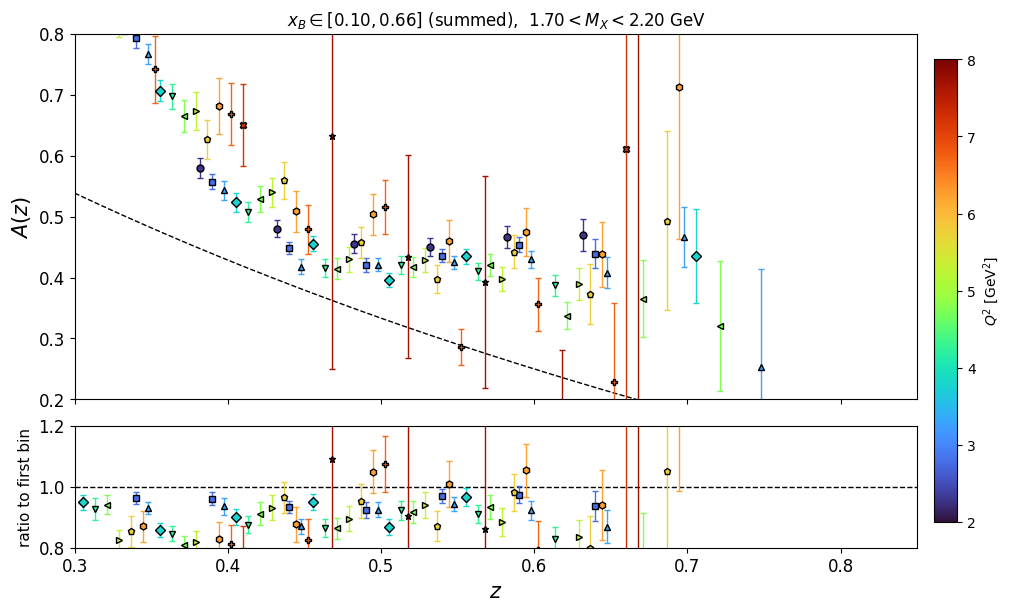

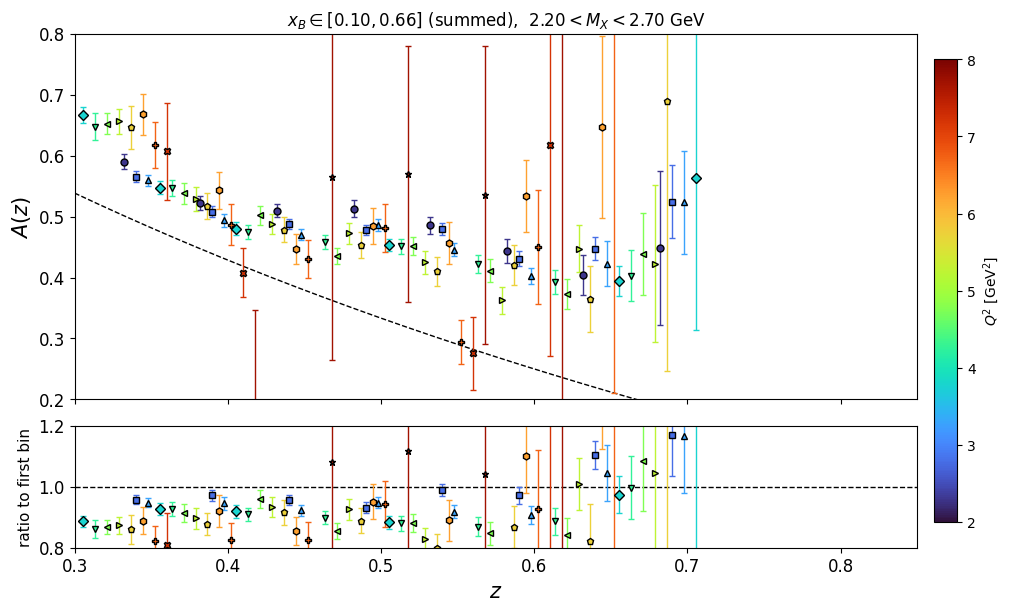

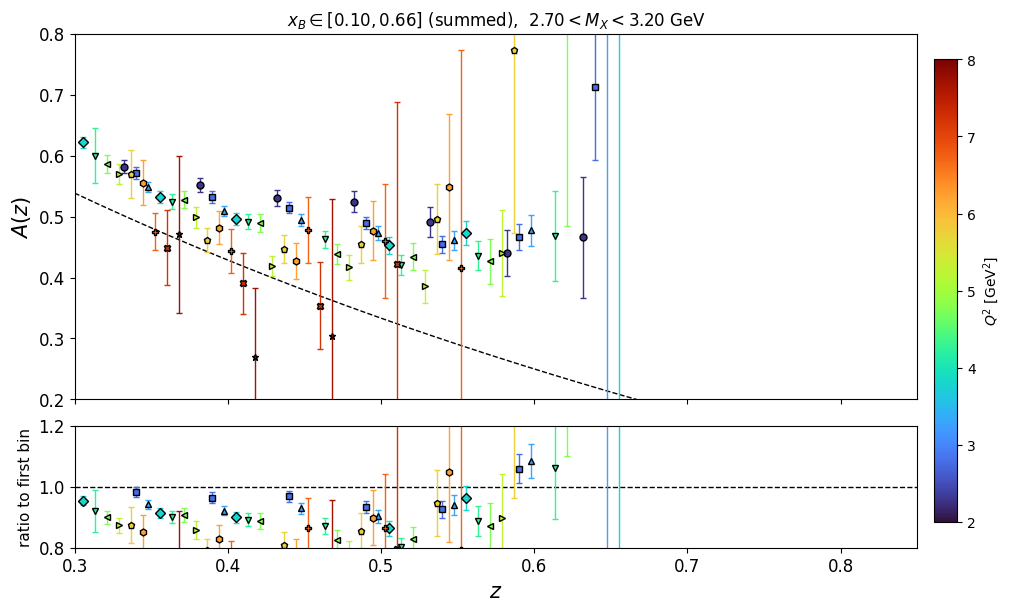

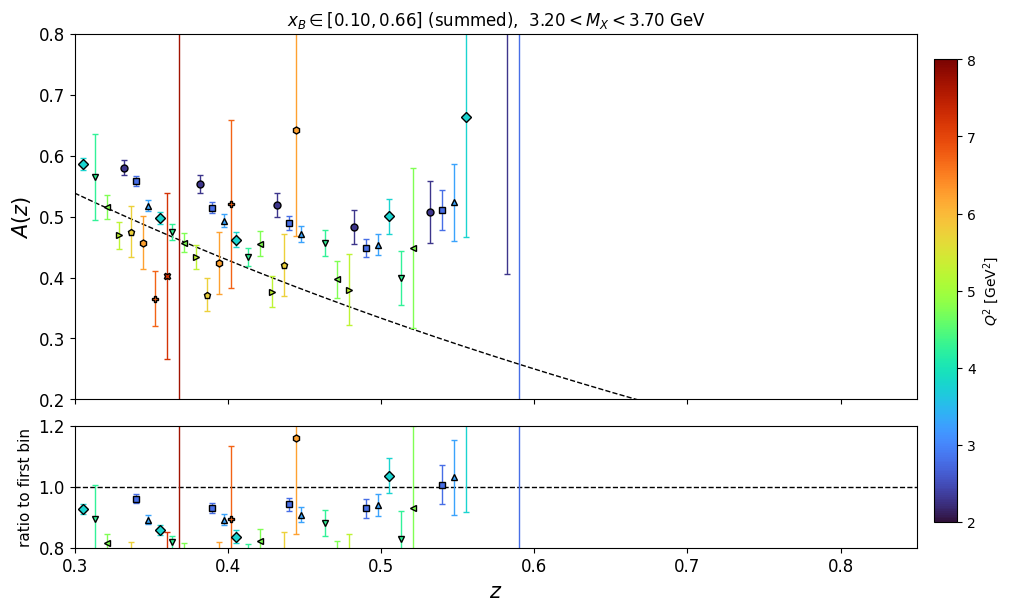

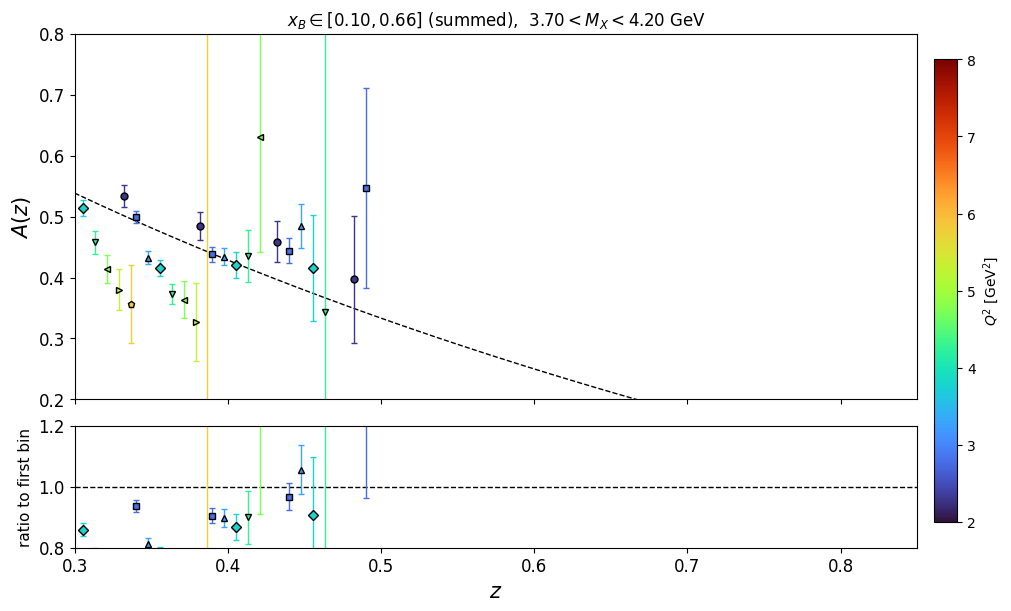

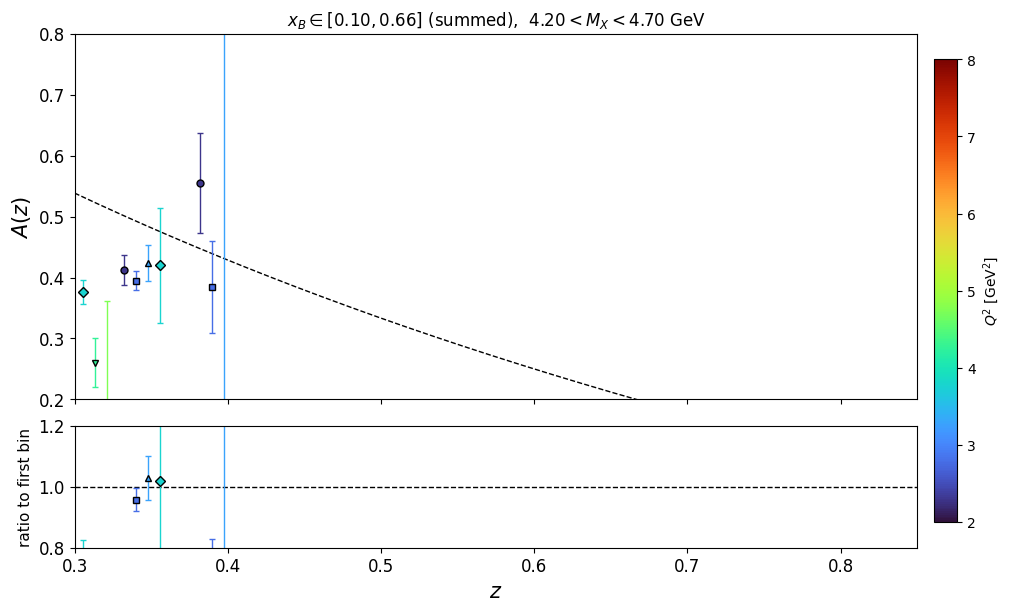

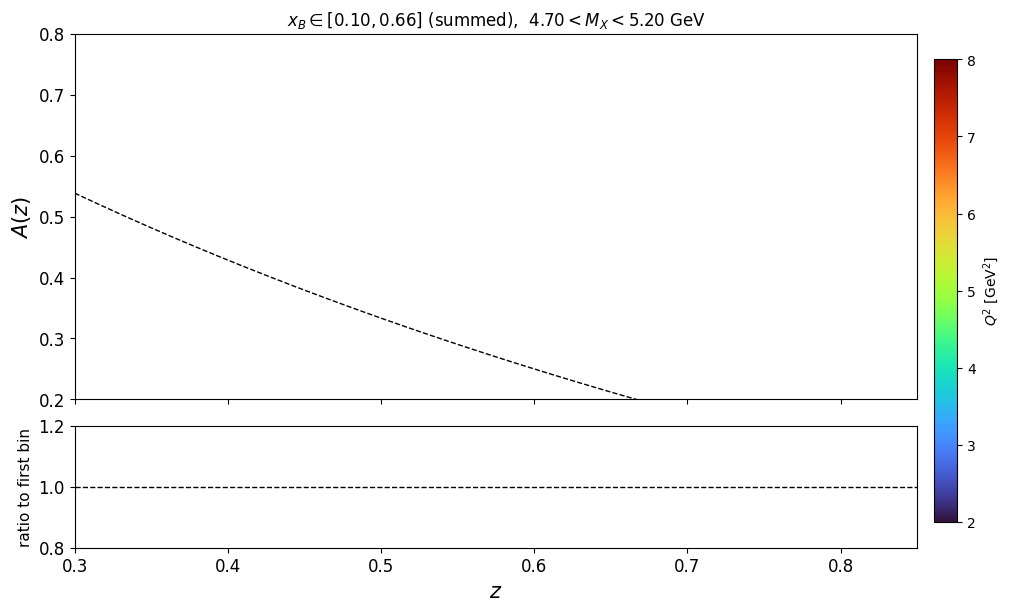

In [184]:
if OVERLAY_Q2 and OVERLAY_XB:
    raise ValueError("Set at most one of OVERLAY_Q2 / OVERLAY_XB to True.")

if OUT_DIR:
    os.makedirs(OUT_DIR, exist_ok=True)

colorList = ['red', 'blue', 'magenta', 'green', 'brown', 'gold',
             'cyan', 'blueviolet', 'darkorange', 'black', 'gray', 'pink']

z_line = np.linspace(0.3, 1.0, 500)

# ── Shared overlay styling (turbo colormap + marker cycle + x-offsets) ─────────
_overlay_cmap    = plt.cm.turbo
_overlay_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', 'P', 'X', '*', 'd', 'H']

def _overlay_style(n):
    """Return (colors, markers, x_offsets) for n overlaid curves."""
    colors   = _overlay_cmap(np.linspace(0.05, 0.95, n))
    markers  = [_overlay_markers[i % len(_overlay_markers)] for i in range(n)]
    z_span   = z_centers[-1] - z_centers[0] if len(z_centers) > 1 else 0.5
    offsets  = np.linspace(-(n - 1) / 2, (n - 1) / 2, n) * (z_span * 0.012)
    return colors, markers, offsets


def fig_title(q_idx, x_idx, var_label=None):
    parts = []
    if OVERLAY_Q2:
        pass  # Q2 range appears in colorbar
    elif SUM_Q2:
        parts.append(rf'$Q^2 \in [{Q2_MIN:.1f}, {Q2_MAX:.1f}]$ GeV$^2$ (summed)')
    else:
        lo = Q2_MIN + q_idx * (Q2_MAX - Q2_MIN) / BINS_Q2
        hi = Q2_MIN + (q_idx + 1) * (Q2_MAX - Q2_MIN) / BINS_Q2
        parts.append(rf'${lo:.1f} < Q^2 < {hi:.1f}$ GeV$^2$')
    if OVERLAY_XB:
        pass  # xB range appears in colorbar
    elif SUM_XB:
        parts.append(rf'$x_B \in [{XB_MIN:.2f}, {XB_MAX:.2f}]$ (summed)')
    else:
        lo = XB_MIN + x_idx * (XB_MAX - XB_MIN) / BINS_XB
        hi = XB_MIN + (x_idx + 1) * (XB_MAX - XB_MIN) / BINS_XB
        parts.append(rf'${lo:.2f} < x_B < {hi:.2f}$')
    if var_range_label:
        parts.append(var_range_label)
    elif var_label:
        parts.append(var_label)
    return ',  '.join(parts)


def _new_fig():
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(10, 6),
        height_ratios=[3, 1], sharex=True, layout='constrained'
    )
    ax_top.plot(z_line, ff(z_line), 'k--', lw=1, zorder=0)
    ax_bot.axhline(1, color='black', linestyle='--', lw=1)
    return fig, ax_top, ax_bot


def _add_errorbar(ax_top, A, A_err, color, label, marker='o', z_plot=None):
    """Plot one A(z) curve; return (A_p, Ae_p) or None if nothing to plot."""
    mask = np.isfinite(A) & (A > 0)
    if not mask.any():
        return None
    A_p   = np.where(mask, A,     np.nan)
    Ae_p  = np.where(mask, A_err, np.nan)
    xvals = z_centers if z_plot is None else z_plot
    ax_top.errorbar(
        xvals, A_p, Ae_p,
        marker=marker, color=color, linestyle='', capsize=2, lw=1, capthick=1,
        markersize=5, mec='black', label=label
    )
    return A_p, Ae_p


def _finish_fig(fig, ax_top, ax_bot, q_idx, x_idx, ref_A, fname_suffix,
                var_label=None, cb_vmin=None, cb_vmax=None, cb_label=None):
    if ref_A is None:
        plt.close(fig)
        return
    ax_top.set_ylabel(r'$A(z)$', fontsize=15)
    ax_top.set_ylim(0.2, .8)
    ax_top.set_xlim(0.3, 0.85)
    ax_top.tick_params(labelsize=12)
    ax_top.set_title(fig_title(q_idx, x_idx, var_label), fontsize=12)
    ax_bot.set_xlabel(r'$z$', fontsize=15)
    ax_bot.set_ylabel('ratio to first bin', fontsize=11)
    ax_bot.set_ylim(0.8, 1.2)
    ax_bot.tick_params(labelsize=12)
    # Overlay modes: replace legend with a colorbar
    if cb_vmin is not None:
        sm = plt.cm.ScalarMappable(
            cmap=_overlay_cmap, norm=plt.Normalize(vmin=cb_vmin, vmax=cb_vmax)
        )
        sm.set_array([])
        fig.colorbar(sm, ax=[ax_top, ax_bot], label=cb_label, shrink=0.9, pad=0.02)
    else:
        ax_top.legend(fontsize=11)
    if OUT_DIR:
        fig.savefig(f"{OUT_DIR}/{fname_suffix}.png", dpi=150)
        plt.close(fig)
    else:
        plt.show()


# ── OVERLAY_Q2: one figure per (var, xB) pair, Q2 bins as curves ──────────────
if OVERLAY_Q2:
    ov_colors, ov_markers, ov_offsets = _overlay_style(n_q2)
    for v in range(n_var):
        var_label = bin_label('var', var_indices[v], BINS_VAR) if (not do_sum_var and BINS_VAR > 1) else None
        for x in range(n_xb):
            fig, ax_top, ax_bot = _new_fig()
            ref_A = None
            for q in range(n_q2):
                z_plot = z_centers + ov_offsets[q]
                result = _add_errorbar(
                    ax_top, A_agg[v, q, x], A_agg_err[v, q, x],
                    ov_colors[q], bin_label('Q2', q, BINS_Q2),
                    marker=ov_markers[q], z_plot=z_plot
                )
                if result is None:
                    continue
                A_p, Ae_p = result
                if ref_A is None:
                    ref_A = A_p
                else:
                    rat, rat_e = ratio_hists(A_p, Ae_p, ref_A, np.zeros_like(ref_A))
                    ax_bot.errorbar(
                        z_plot, rat, rat_e,
                        marker=ov_markers[q], color=ov_colors[q],
                        linestyle='', capsize=2, lw=1, capthick=1,
                        markersize=5, mec='black'
                    )
            fname = f"ratio_q2overlay_v{v+1}_{x+1}" if n_var > 1 else f"ratio_q2overlay_{x+1}"
            _finish_fig(fig, ax_top, ax_bot, -1, x, ref_A, fname, var_label,
                        cb_vmin=Q2_MIN, cb_vmax=Q2_MAX, cb_label=r'$Q^2\ \mathrm{[GeV^2]}$')

# ── OVERLAY_XB: one figure per (var, Q2) pair, xB bins as curves ──────────────
elif OVERLAY_XB:
    ov_colors, ov_markers, ov_offsets = _overlay_style(n_xb)
    for v in range(n_var):
        var_label = bin_label('var', var_indices[v], BINS_VAR) if (not do_sum_var and BINS_VAR > 1) else None
        for q in range(n_q2):
            fig, ax_top, ax_bot = _new_fig()
            ref_A = None
            for x in range(n_xb):
                z_plot = z_centers + ov_offsets[x]
                result = _add_errorbar(
                    ax_top, A_agg[v, q, x], A_agg_err[v, q, x],
                    ov_colors[x], bin_label('xB', x, BINS_XB),
                    marker=ov_markers[x], z_plot=z_plot
                )
                if result is None:
                    continue
                A_p, Ae_p = result
                if ref_A is None:
                    ref_A = A_p
                else:
                    rat, rat_e = ratio_hists(A_p, Ae_p, ref_A, np.zeros_like(ref_A))
                    ax_bot.errorbar(
                        z_plot, rat, rat_e,
                        marker=ov_markers[x], color=ov_colors[x],
                        linestyle='', capsize=2, lw=1, capthick=1,
                        markersize=5, mec='black'
                    )
            fname = f"ratio_xboverlay_v{v+1}_{q+1}" if n_var > 1 else f"ratio_xboverlay_{q+1}"
            _finish_fig(fig, ax_top, ax_bot, q, -1, ref_A, fname, var_label,
                        cb_vmin=XB_MIN, cb_vmax=XB_MAX, cb_label=r'$x_B$')

# ── Original: one figure per (Q2, xB) pair, var bins as curves ────────────────
else:
    for q in range(n_q2):
        for x in range(n_xb):
            fig, ax_top, ax_bot = _new_fig()
            ref_A = None
            for v in range(n_var):
                if do_sum_var:
                    label = var_range_label or 'summed'
                elif BINS_VAR > 1:
                    label = bin_label('var', var_indices[v], BINS_VAR)
                else:
                    label = 'data'
                result = _add_errorbar(
                    ax_top, A_agg[v, q, x], A_agg_err[v, q, x],
                    colorList[v % len(colorList)], label
                )
                if result is None:
                    continue
                A_p, Ae_p = result
                if ref_A is None:
                    ref_A = A_p
                else:
                    rat, rat_e = ratio_hists(A_p, Ae_p, ref_A, np.zeros_like(ref_A))
                    ax_bot.errorbar(
                        z_centers, rat, rat_e,
                        marker='o', color=colorList[v % len(colorList)],
                        linestyle='', capsize=2, lw=1, capthick=1,
                        markersize=5, mec='black'
                    )
            _finish_fig(fig, ax_top, ax_bot, q, x, ref_A, f"ratio_{q+1}_{x+1}")

## (Optional) Inspect raw components for a single bin

IndexError: index 4 is out of bounds for axis 2 with size 1

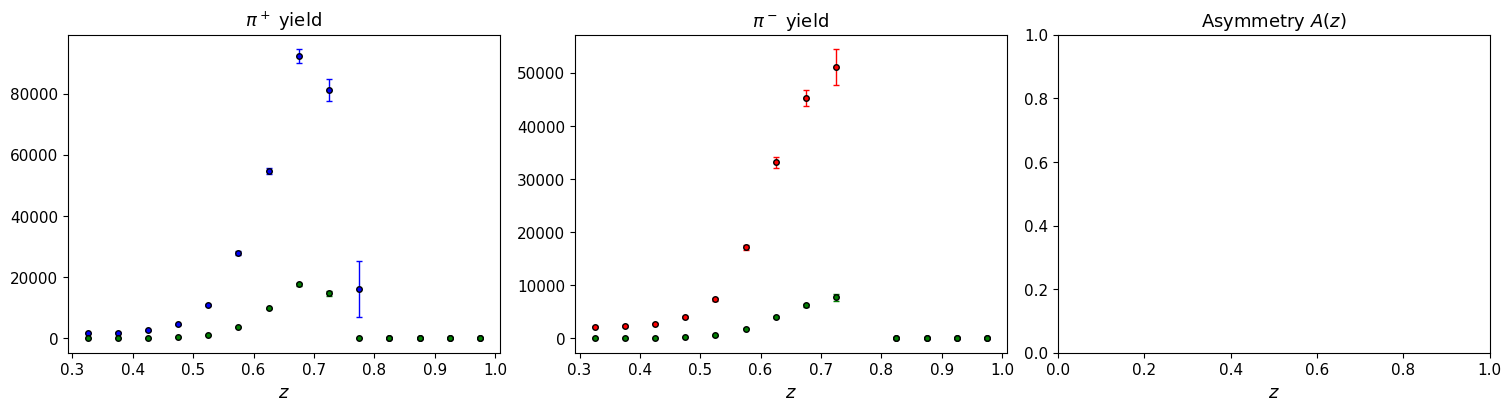

In [185]:
# 0-based indices into the *original* (un-aggregated) arrays
Q_INSPECT   = 3
X_INSPECT   = 4
VAR_INSPECT = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 4), layout='constrained')
for ax, title in zip(axes, [r'$\pi^+$ yield', r'$\pi^-$ yield', r'Asymmetry $A(z)$']):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(r'$z$', fontsize=13)
    ax.tick_params(labelsize=11)

def _plot_raw(ax, name, label, color):
    dat = get_hist(inFile, name)
    if dat is None:
        return
    v, e, c = dat
    ax.errorbar(c, v, e, marker='o', color=color, linestyle='',
                capsize=2, lw=1, markersize=4, mec='black', label=label)

v, q, x = VAR_INSPECT, Q_INSPECT, X_INSPECT
_plot_raw(axes[0], hist_name('hRatio', v, '',     q, x), r'$\pi^+$', 'blue')
_plot_raw(axes[1], hist_name('hRatio', v, '_Pim', q, x), r'$\pi^-$', 'red')

if APPLY_CORR > 3:
    _plot_raw(axes[0], hist_name('hRatio_k', v, '',     q, x), 'kaon+', 'green')
    _plot_raw(axes[1], hist_name('hRatio_k', v, '_Pim', q, x), 'kaon−', 'green')
if APPLY_CORR > 4:
    _plot_raw(axes[0], hist_name('hRatio_r', v, '',     q, x), 'rho+', 'orange')
    _plot_raw(axes[1], hist_name('hRatio_r', v, '_Pim', q, x), 'rho−', 'orange')

A_ins   = A_agg    [v, q, x]
Ae_ins  = A_agg_err[v, q, x]
axes[2].errorbar(z_centers, A_ins, Ae_ins, marker='o', color='black',
                 linestyle='', capsize=2, lw=1, markersize=4, mec='black', label='A(z)')
axes[2].plot(z_line, ff(z_line), 'k--', lw=1, label='FF')
axes[2].set_ylim(0, 1)
axes[2].legend(fontsize=10)

for ax in axes[:2]:
    ax.legend(fontsize=10)

q2_lo = Q2_MIN + q * (Q2_MAX - Q2_MIN) / BINS_Q2
xb_lo = XB_MIN + x * (XB_MAX - XB_MIN) / BINS_XB
fig.suptitle(rf'$Q^2$ bin {q+1} ($\approx${q2_lo:.1f} GeV$^2$),  '
             rf'$x_B$ bin {x+1} ($\approx${xb_lo:.2f})', fontsize=13)
plt.show()

## Fixed-bin overlay (plotFixedZ style)

One figure per outer bin; inner-dimension bins shown as overlaid curves.
The bottom panel shows `quantity / FF(z)` — deviations from the FF shape.

In [ ]:
# Which quantity to plot on the top panel
# 'A'  →  asymmetry A(z) = (4 - r) / (4r - 1)
# 'r'  →  raw charge ratio r(z) = π⁺ / π⁻
FZ_QUANTITY = 'A'

# Outer loop dimension (sets which variable is fixed per figure)
# 'xB'  →  one figure per xB bin, inner curves are Q2 bins  (matches plotFixedZ.py)
# 'Q2'  →  one figure per Q2 bin, inner curves are xB bins
FZ_OUTER = 'xB'

# Output directory (None = display inline)
FZ_OUT_DIR = None  # e.g. "fixedbin_plots"

## Kinematic dependence at fixed z

Grid of panels — one per z bin — each showing how A (or r) varies with Q² or xB.
Different curves correspond to the orthogonal kinematic dimension.

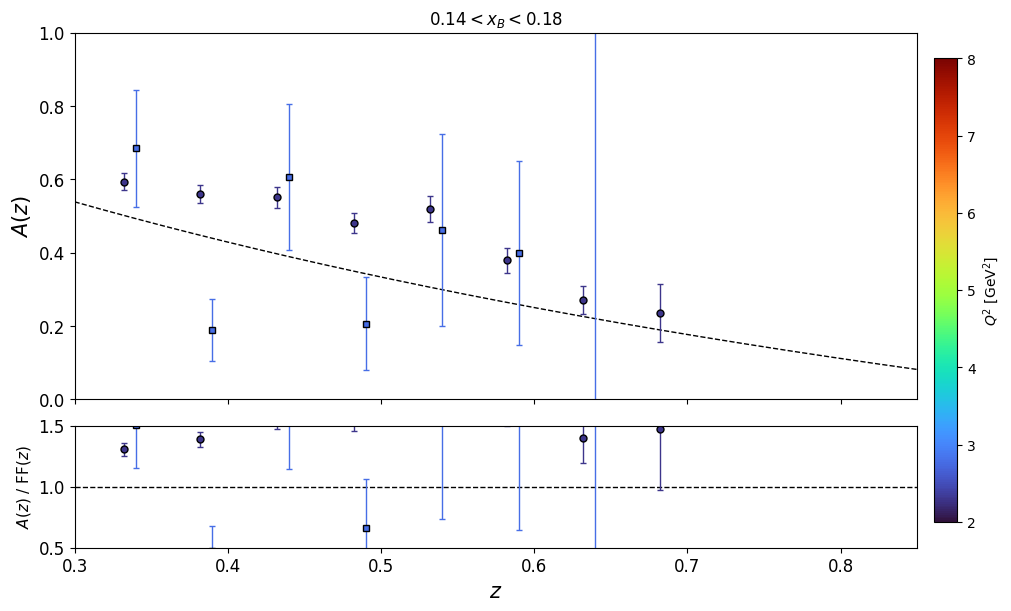

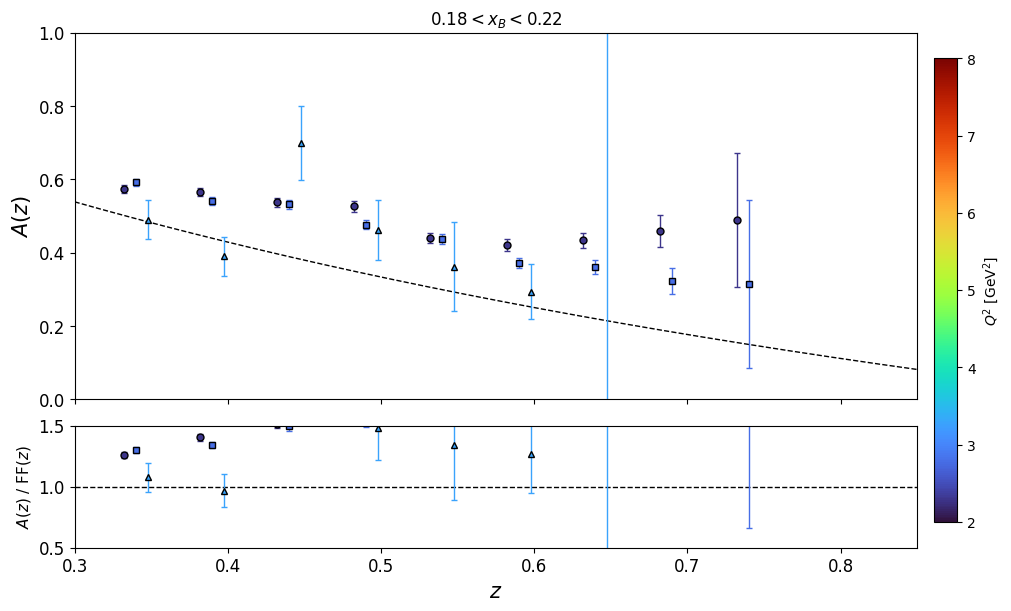

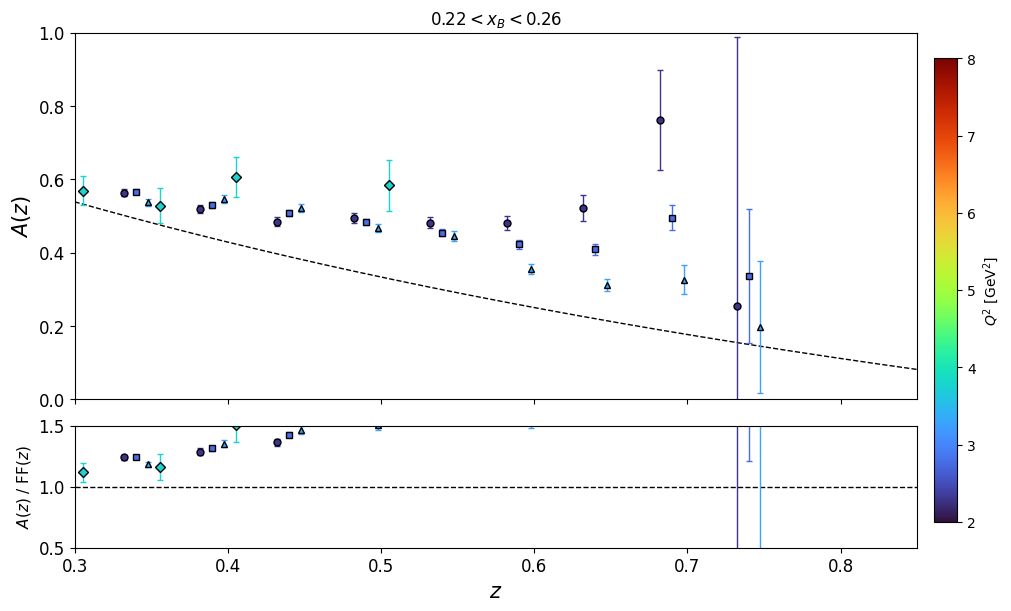

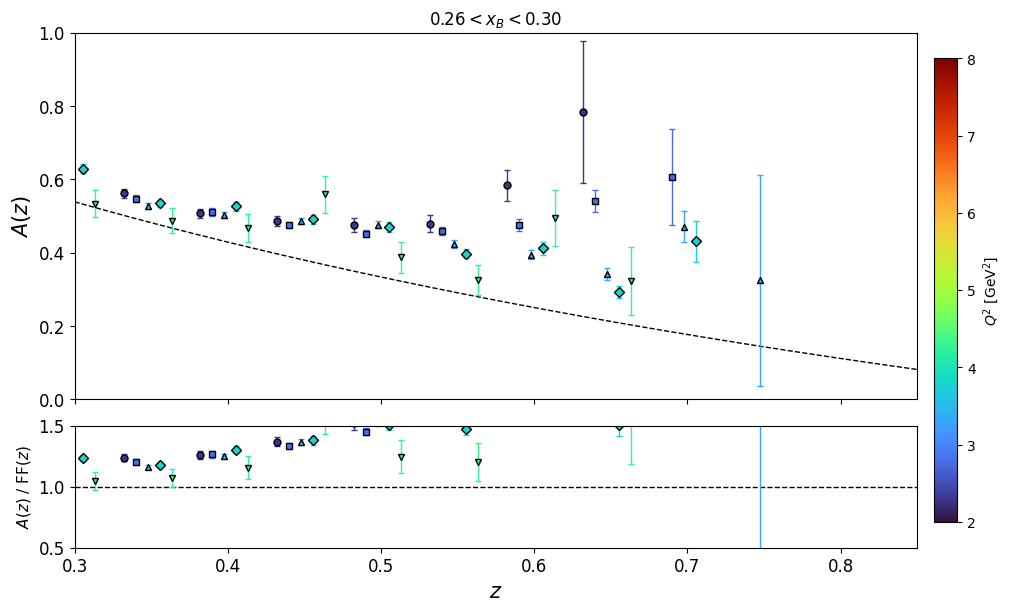

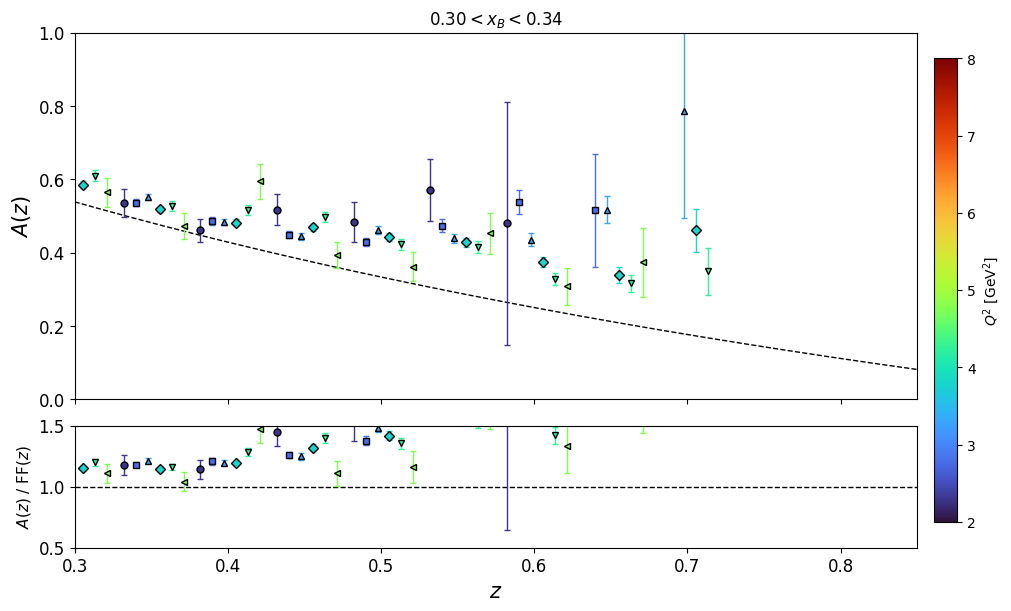

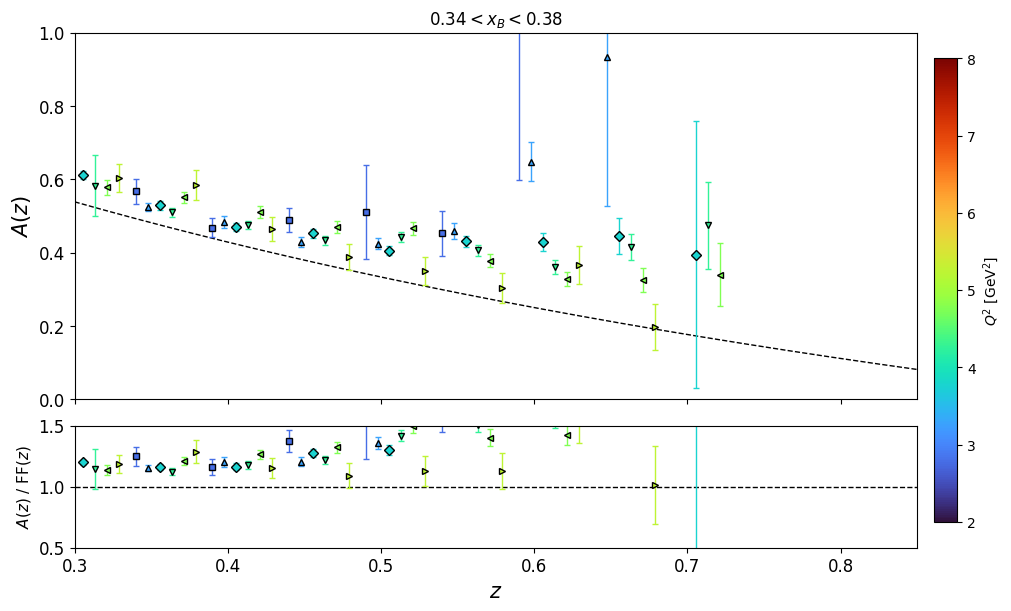

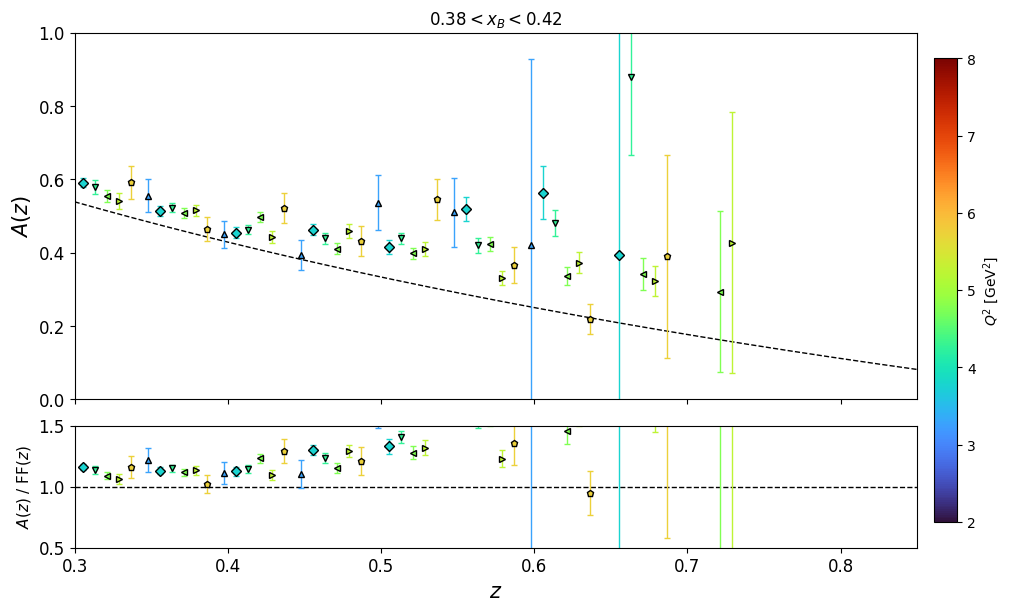

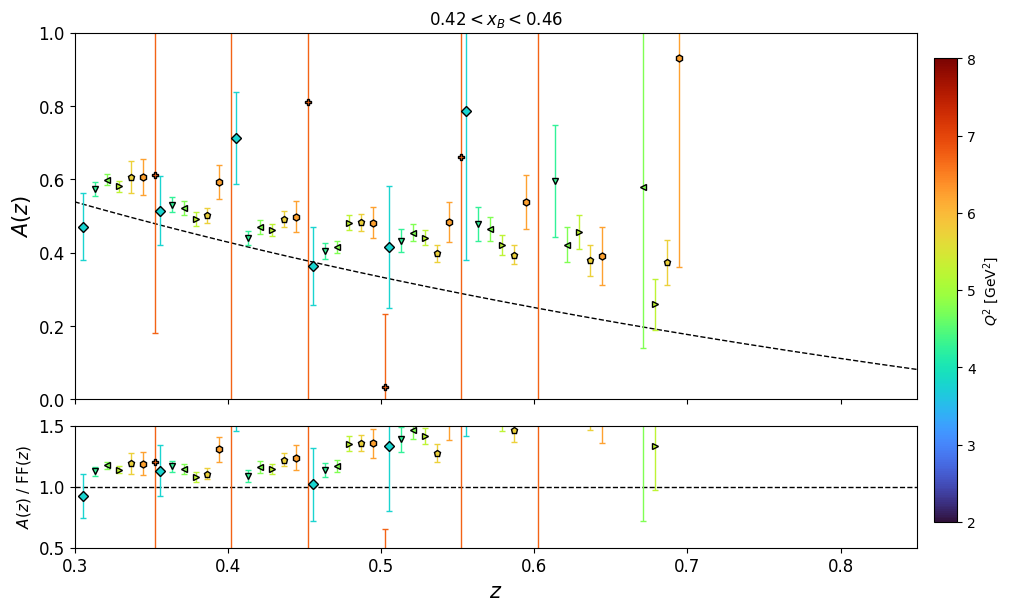

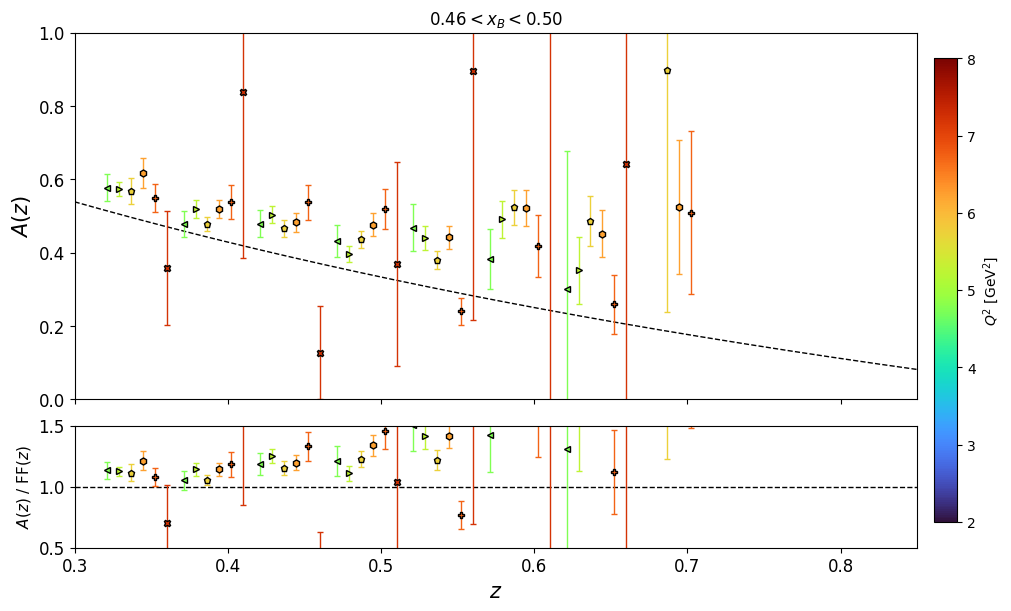

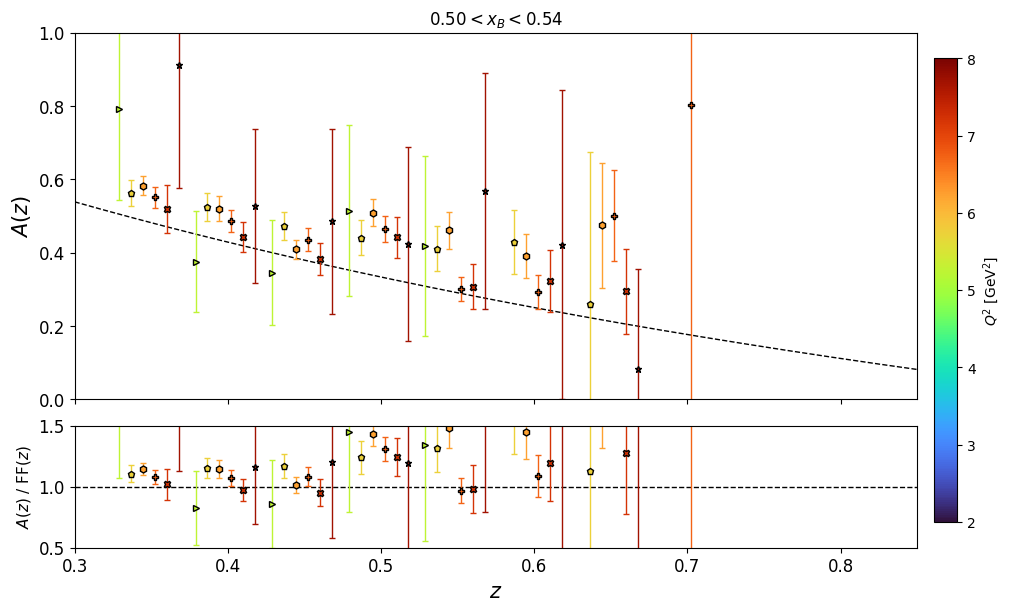

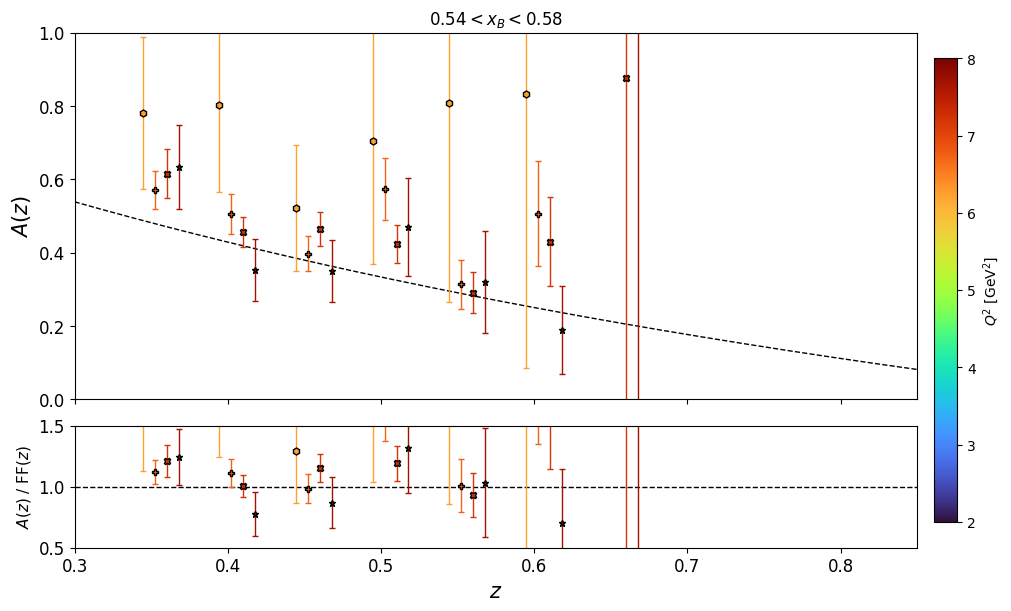

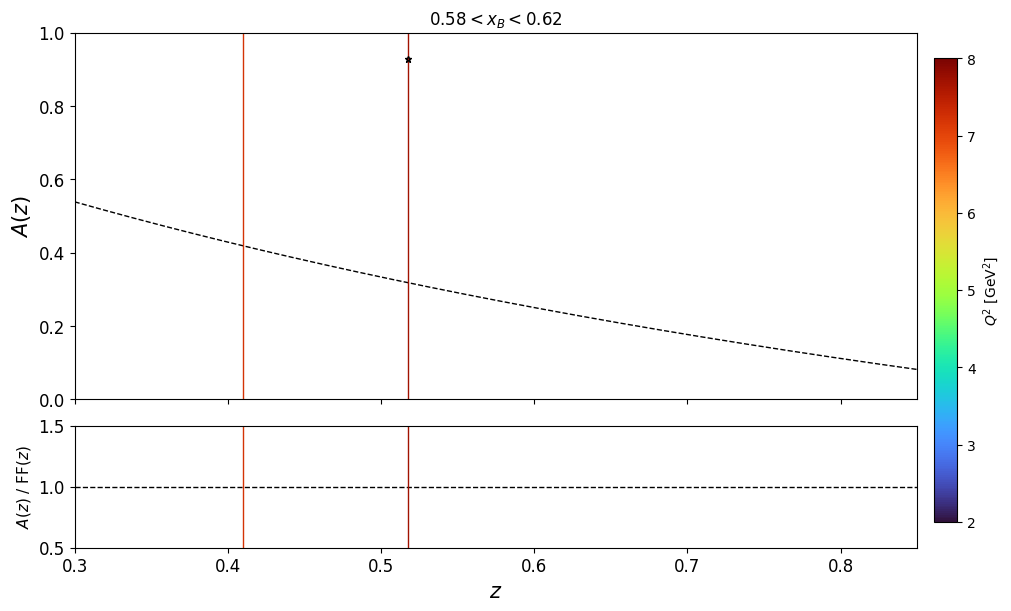

In [ ]:
if FZ_OUT_DIR:
    os.makedirs(FZ_OUT_DIR, exist_ok=True)

if n_var > 1:
    print("Note: fixed-bin overlay uses v=0 only. Set SUM_VAR=True for a cleaner result.")

# Select the quantity to display
if FZ_QUANTITY == 'r':
    fz_vals  = r_agg
    fz_errs  = r_agg_err
    fz_label = r'$r(z)$'
else:
    fz_vals  = A_agg
    fz_errs  = A_agg_err
    fz_label = r'$A(z)$'

# Determine outer/inner loop sizes and labels
if FZ_OUTER == 'xB':
    n_outer   = n_xb
    n_inner   = n_q2
    inner_dim = 'Q2'
    def _fz_title(outer_idx):
        lo = XB_MIN + outer_idx * (XB_MAX - XB_MIN) / BINS_XB
        hi = XB_MIN + (outer_idx + 1) * (XB_MAX - XB_MIN) / BINS_XB
        return rf'${lo:.2f} < x_B < {hi:.2f}$'
    def _fz_indices(outer, inner):
        return inner, outer
    cb_vmin, cb_vmax = Q2_MIN, Q2_MAX
    cb_label_fz = r'$Q^2\ \mathrm{[GeV^2]}$'
else:  # 'Q2'
    n_outer   = n_q2
    n_inner   = n_xb
    inner_dim = 'xB'
    def _fz_title(outer_idx):
        lo = Q2_MIN + outer_idx * (Q2_MAX - Q2_MIN) / BINS_Q2
        hi = Q2_MIN + (outer_idx + 1) * (Q2_MAX - Q2_MIN) / BINS_Q2
        return rf'${lo:.1f} < Q^2 < {hi:.1f}$ GeV$^2$'
    def _fz_indices(outer, inner):
        return outer, inner
    cb_vmin, cb_vmax = XB_MIN, XB_MAX
    cb_label_fz = r'$x_B$'

fz_z_line = np.linspace(0.3, 1.0, 500)
ff_at_z   = ff(z_centers)

# ── Curve styling ──────────────────────────────────────────────────────────────
fz_cmap    = plt.cm.turbo
fz_colors  = fz_cmap(np.linspace(0.05, 0.95, n_inner))
fz_markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', 'h', 'P', 'X', '*', 'd', 'H']

# Small x-offset per curve so error bars don't pile up
z_span  = z_centers[-1] - z_centers[0] if len(z_centers) > 1 else 0.5
x_step  = z_span * 0.012          # total spread ~ 1.2 % of z range per curve
x_offsets = np.linspace(-(n_inner - 1) / 2, (n_inner - 1) / 2, n_inner) * x_step

for outer in range(n_outer):
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(10, 6),
        height_ratios=[3, 1], sharex=True, layout='constrained'
    )
    ax_top.plot(fz_z_line, ff(fz_z_line), 'k--', lw=1, zorder=0)
    ax_bot.axhline(1, color='black', linestyle='--', lw=1)

    has_data = False
    for inner in range(n_inner):
        q, x = _fz_indices(outer, inner)
        qty     = fz_vals[0, q, x]
        qty_err = fz_errs[0, q, x]

        mask = np.isfinite(qty) & (qty > 0)
        if not mask.any():
            continue
        qty_p  = np.where(mask, qty,     np.nan)
        qte_p  = np.where(mask, qty_err, np.nan)

        color  = fz_colors[inner]
        marker = fz_markers[inner % len(fz_markers)]
        z_plot = z_centers + x_offsets[inner]

        ax_top.errorbar(
            z_plot, qty_p, qte_p,
            marker=marker, color=color, linestyle='',
            capsize=2, lw=1, capthick=1, markersize=5, mec='black'
        )

        with np.errstate(invalid='ignore', divide='ignore'):
            ff_ratio     = np.where(ff_at_z != 0, qty_p / ff_at_z, np.nan)
            ff_ratio_err = np.where(ff_at_z != 0, qte_p / np.abs(ff_at_z), np.nan)

        ax_bot.errorbar(
            z_plot, ff_ratio, ff_ratio_err,
            marker=marker, color=color, linestyle='',
            capsize=2, lw=1, capthick=1, markersize=5, mec='black'
        )
        has_data = True

    if not has_data:
        plt.close(fig)
        continue

    # Colorbar encodes the inner-dimension physical value
    sm = plt.cm.ScalarMappable(
        cmap=fz_cmap, norm=plt.Normalize(vmin=cb_vmin, vmax=cb_vmax)
    )
    sm.set_array([])
    fig.colorbar(sm, ax=[ax_top, ax_bot], label=cb_label_fz, shrink=0.9, pad=0.02)

    ax_top.set_ylabel(fz_label, fontsize=15)
    ax_top.set_ylim(0, 1)
    ax_top.set_xlim(0.3, 0.85)
    ax_top.tick_params(labelsize=12)
    ax_top.set_title(_fz_title(outer), fontsize=12)

    ax_bot.set_xlabel(r'$z$', fontsize=15)
    ax_bot.set_ylabel(fz_label + r' / FF$(z)$', fontsize=11)
    ax_bot.set_ylim(0.5, 1.5)
    ax_bot.tick_params(labelsize=12)

    if FZ_OUT_DIR:
        fig.savefig(f"{FZ_OUT_DIR}/fixedbin_{outer+1}.png", dpi=150)
        plt.close(fig)
    else:
        plt.show()

In [ ]:
# 'A' for asymmetry A(z), 'r' for raw charge ratio r(z)
KD_QUANTITY = 'A'

# X-axis of the kinematic-dependence grid:
# 'Q2' → A vs Q², one panel per z bin, xB bins as colour-coded curves
# 'xB' → A vs xB, one panel per z bin, Q2 bins as colour-coded curves
KD_X_AXIS = 'xB'

# Output directory (None = display inline)
KD_OUT_DIR = None  # e.g. "kd_plots"

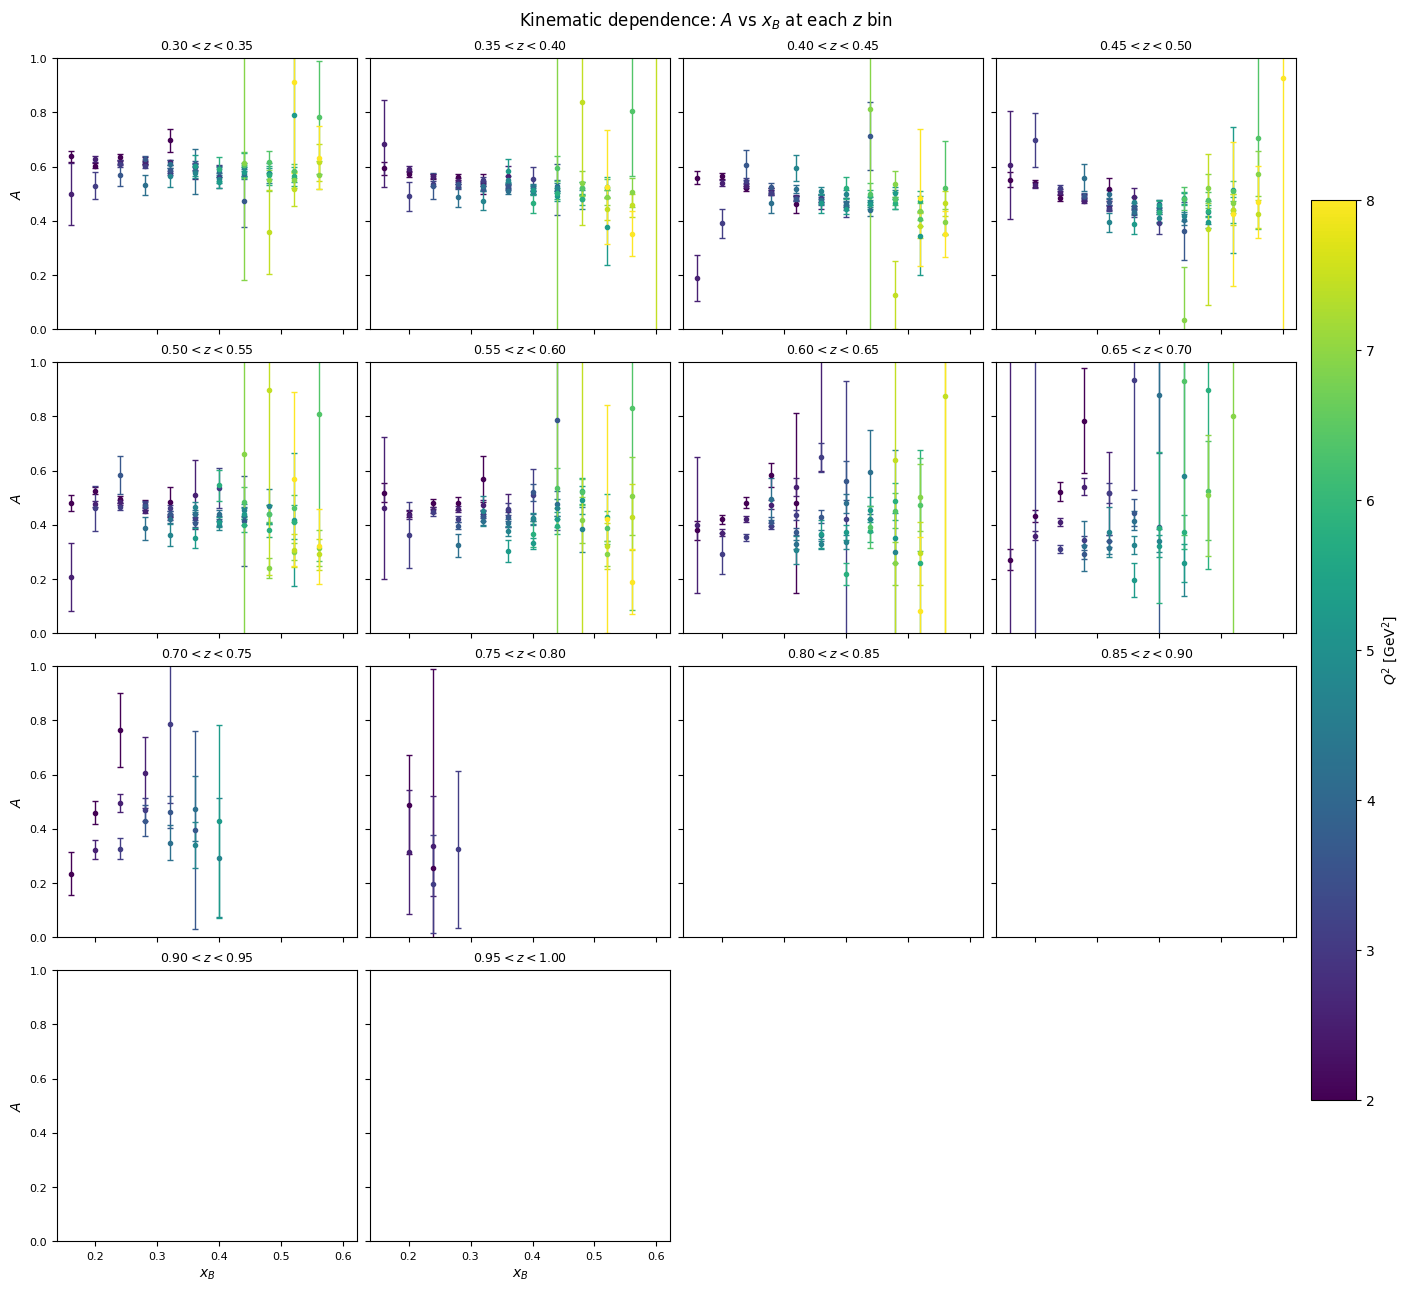

In [ ]:
n_z = A_agg.shape[3]

# Infer z bin edges from bin centres
if n_z > 1:
    dz = z_centers[1] - z_centers[0]
else:
    dz = 0.05
z_lo_arr = z_centers - dz / 2
z_hi_arr = z_centers + dz / 2

# Kinematic axis bin centres (uniform grid)
q2_ctrs = Q2_MIN + (np.arange(n_q2) + 0.5) * (Q2_MAX - Q2_MIN) / n_q2
xb_ctrs = XB_MIN + (np.arange(n_xb) + 0.5) * (XB_MAX - XB_MIN) / n_xb

# Select quantity
if KD_QUANTITY == 'r':
    kd_vals  = r_agg
    kd_errs  = r_agg_err
    kd_label = r'$r$'
else:
    kd_vals  = A_agg
    kd_errs  = A_agg_err
    kd_label = r'$A$'

# Colour map: one colour per inner curve (xB or Q2 bins)
if KD_X_AXIS == 'Q2':
    n_curves = n_xb
    x_ctrs   = q2_ctrs
    x_label  = r'$Q^2\ \mathrm{[GeV^2]}$'
    cb_label = r'$x_B$'
    cb_norm  = plt.Normalize(vmin=XB_MIN, vmax=XB_MAX)
else:  # 'xB'
    n_curves = n_q2
    x_ctrs   = xb_ctrs
    x_label  = r'$x_B$'
    cb_label = r'$Q^2\ \mathrm{[GeV^2]}$'
    cb_norm  = plt.Normalize(vmin=Q2_MIN, vmax=Q2_MAX)

cmap   = plt.cm.viridis
colors_kd = cmap(np.linspace(0, 1, n_curves))

# Grid layout: 4 columns, enough rows for all z bins
n_cols_kd = 4
n_rows_kd = int(np.ceil(n_z / n_cols_kd))

fig, axs = plt.subplots(
    n_rows_kd, n_cols_kd,
    figsize=(14, n_rows_kd * 3.2),
    sharex=True, sharey=True, layout='constrained'
)

for z_idx in range(n_z):
    ax = axs.flat[z_idx]

    for ci in range(n_curves):
        if KD_X_AXIS == 'Q2':
            vals = kd_vals[0, :, ci, z_idx]   # shape (n_q2,)
            errs = kd_errs[0, :, ci, z_idx]
        else:
            vals = kd_vals[0, ci, :, z_idx]   # shape (n_xb,)
            errs = kd_errs[0, ci, :, z_idx]

        mask = np.isfinite(vals) & (vals > 0)
        if not mask.any():
            continue

        ax.errorbar(
            x_ctrs[mask], vals[mask], errs[mask],
            marker='o', color=colors_kd[ci], linestyle='',
            capsize=2, lw=1, capthick=1, markersize=3
        )

    ax.set_title(rf'${z_lo_arr[z_idx]:.2f} < z < {z_hi_arr[z_idx]:.2f}$', fontsize=9)
    ax.set_ylim(0, 1)
    ax.tick_params(labelsize=8)

# Hide unused panels
for k in range(n_z, n_rows_kd * n_cols_kd):
    axs.flat[k].set_visible(False)

# Axis labels on outer edges only
for ax in axs[-1]:
    if ax.get_visible():
        ax.set_xlabel(x_label, fontsize=10)
for ax in axs[:, 0]:
    ax.set_ylabel(kd_label, fontsize=10)

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=cb_norm)
sm.set_array([])
fig.colorbar(sm, ax=axs[:, -1].tolist(), label=cb_label, shrink=0.8)

fig.suptitle(
    rf'Kinematic dependence: {kd_label} vs {x_label} at each $z$ bin',
    fontsize=12
)

if KD_OUT_DIR:
    os.makedirs(KD_OUT_DIR, exist_ok=True)
    fig.savefig(f"{KD_OUT_DIR}/kd_{KD_X_AXIS}.png", dpi=150)
    plt.close(fig)
else:
    plt.show()

## Aggregate over selected dimensions

Summation happens at the Pi+/Pi− yield level (before the ratio), so errors are
added in quadrature. Using `keepdims=True` keeps the array shape at 4-D;
summed axes collapse to size 1 and are then iterated over a single index.

## Aggregate over selected dimensions

Summation happens at the Pi+/Pi− yield level (before the ratio), so errors are
added in quadrature. Using `keepdims=True` keeps the array shape at 4-D;
summed axes collapse to size 1 and are then iterated over a single index.

## Aggregate over selected dimensions

Summation happens at the Pi+/Pi− yield level (before the ratio), so errors are
added in quadrature. Using `keepdims=True` keeps the array shape at 4-D;
summed axes collapse to size 1 and are then iterated over a single index.